In [427]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

In [428]:
pd.__version__

'2.3.1'

In [429]:
np.__version__

'2.3.2'

In [430]:
import matplotlib
matplotlib.__version__

'3.10.5'

In [431]:
df = pd.read_csv("brain_stroke.csv")

In [432]:
# train set 80% and test set 20%
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

In [433]:
df_train

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4260,Female,56.00,0.0,0.0,Yes,Self-employed,Urban,98.14,32.7,formerly smoked,0
1658,Male,35.00,0.0,0.0,Yes,Private,Urban,82.81,23.9,never smoked,0
1151,Male,15.00,0.0,0.0,No,Private,Rural,78.59,25.1,Unknown,0
3975,Male,55.00,0.0,0.0,Yes,Private,Rural,80.35,28.7,smokes,0
647,Female,13.00,0.0,0.0,No,children,Rural,63.26,19.5,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
4426,Female,54.00,0.0,0.0,Yes,Govt_job,Urban,231.54,29.9,never smoked,0
466,Female,38.00,0.0,0.0,Yes,Govt_job,Urban,70.92,41.6,never smoked,0
3092,Male,13.00,0.0,0.0,No,Private,Rural,90.60,16.9,never smoked,0
3772,Female,0.48,0.0,0.0,No,children,Rural,118.75,17.4,Unknown,0


In [434]:
df_test

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1129,Female,65.00,1.0,0.0,Yes,Private,Urban,180.76,26.9,Unknown,0
3671,Female,11.00,0.0,0.0,No,children,Rural,93.51,20.8,Unknown,0
1041,Male,1.56,0.0,0.0,No,children,Rural,93.74,20.1,Unknown,0
2072,Female,49.00,0.0,0.0,Yes,Self-employed,Rural,68.44,23.0,smokes,0
1375,Female,49.00,1.0,0.0,Yes,Govt_job,Rural,107.91,25.0,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
2164,Female,80.00,0.0,0.0,Yes,Self-employed,Urban,75.06,29.7,Unknown,0
2423,Female,46.00,0.0,0.0,Yes,Govt_job,Urban,56.89,23.8,smokes,0
1629,Female,47.00,0.0,0.0,Yes,Private,Urban,56.67,24.4,never smoked,0
2299,Male,0.88,0.0,0.0,No,children,Urban,90.62,22.4,Unknown,0


In [435]:
df_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4260,Female,56.0,0.0,0.0,Yes,Self-employed,Urban,98.14,32.7,formerly smoked,0
1658,Male,35.0,0.0,0.0,Yes,Private,Urban,82.81,23.9,never smoked,0
1151,Male,15.0,0.0,0.0,No,Private,Rural,78.59,25.1,Unknown,0
3975,Male,55.0,0.0,0.0,Yes,Private,Rural,80.35,28.7,smokes,0
647,Female,13.0,0.0,0.0,No,children,Rural,63.26,19.5,Unknown,0


In [436]:
df_train.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,3486.000000,3485.000000,3484.000000,3482.000000,3486.000000,3486.000000
mean,43.496615,0.092396,0.052239,106.013550,28.549656,0.048766
std,22.901598,0.289626,0.222540,45.132491,6.781029,0.215410
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.322500,23.700000,0.000000
50%,45.000000,0.000000,0.000000,92.085000,28.200000,0.000000
75%,62.000000,0.000000,0.000000,113.680000,32.700000,0.000000
max,82.000000,1.000000,1.000000,267.760000,48.900000,1.000000


In [437]:
df['stroke'].value_counts(normalize=True)
df['stroke'].value_counts()


stroke
0    4733
1     248
Name: count, dtype: int64

In [438]:
df_train['stroke'].value_counts()


stroke
0    3316
1     170
Name: count, dtype: int64

In [439]:
import pandas as pd
from sklearn.utils import resample

# Function to balance dataset
def balance_dataset(data, target_col, n_samples):


    # 1. Separate the data into two groups
    majority = data[data[target_col] == 0]   # all rows with 0
    minority = data[data[target_col] == 1]   # all rows with 1

    majoritygroup = resample(majority,
                          replace=False,
                          n_samples=n_samples,
                          random_state=134)
    
    minoritygroup = resample(minority,
                          replace=False,
                          n_samples=n_samples,
                          random_state=134)


    balanced_data = pd.concat([majoritygroup, minoritygroup])

    return balanced_data

# Make train balanced (200 rows of each class)
df_train = balance_dataset(df, target_col="stroke", n_samples=200)

# Make test balanced (48 rows of each class)
df_test = balance_dataset(df, target_col="stroke", n_samples=48)

# See the results
print("Train balanced counts:\n", df_train["stroke"].value_counts())
print("Test balanced counts:\n", df_test["stroke"].value_counts())

Train balanced counts:
 stroke
0    200
1    200
Name: count, dtype: int64
Test balanced counts:
 stroke
0    48
1    48
Name: count, dtype: int64


In [440]:
df_train['avg_glucose_level'].max()

np.float64(271.74)

In [441]:
condMaxAi = df_train['avg_glucose_level'] == 271.74
df_train[condMaxAi]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
157,Male,68.0,1.0,1.0,Yes,Private,Rural,271.74,31.1,smokes,1


In [442]:
df_train.loc[157]

gender                  Male
age                     68.0
hypertension             1.0
heart_disease            1.0
ever_married             Yes
work_type            Private
Residence_type         Rural
avg_glucose_level     271.74
bmi                     31.1
smoking_status        smokes
stroke                     1
Name: 157, dtype: object

In [443]:
df_train['ever_married'].value_counts()

ever_married
Yes    303
No      96
Name: count, dtype: int64

In [444]:
df_train.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [445]:
df_train.dtypes

gender                object
age                  float64
hypertension         float64
heart_disease        float64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [446]:
print(df_train.columns.tolist())

['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [447]:
df_train['gender'] = le.fit_transform(df_train['gender'])
df_test['gender']  = le.transform(df_test['gender'])


In [448]:
df_train['work_type'] = le.fit_transform(df_train['work_type'])
df_test['work_type']  = le.transform(df_test['work_type'])


In [449]:
df_train.dtypes


gender                 int64
age                  float64
hypertension         float64
heart_disease        float64
ever_married          object
work_type              int64
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [450]:
df_train['smoking_status'] = le.fit_transform(df_train['smoking_status'])
df_test['smoking_status']  = le.transform(df_test['smoking_status'])


In [451]:
df_train['Residence_type'] = le.fit_transform(df_train['Residence_type'])
df_test['Residence_type']  = le.transform(df_test['Residence_type'])

In [452]:
df_train.dtypes

gender                 int64
age                  float64
hypertension         float64
heart_disease        float64
ever_married          object
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
dtype: object

In [453]:
df_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1514,1,54.0,0.0,0.0,Yes,1,0,109.51,29.0,2,0
1104,1,64.0,1.0,0.0,Yes,1,0,78.43,30.2,3,0
3446,0,39.0,0.0,0.0,Yes,1,0,103.12,29.9,1,0
1529,0,52.0,0.0,0.0,Yes,0,0,69.11,35.2,2,0
3929,1,38.0,0.0,0.0,Yes,1,1,167.16,18.3,2,0


In [454]:
df_train.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [455]:
df_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1514,1,54.0,0.0,0.0,Yes,1,0,109.51,29.0,2,0
1104,1,64.0,1.0,0.0,Yes,1,0,78.43,30.2,3,0
3446,0,39.0,0.0,0.0,Yes,1,0,103.12,29.9,1,0
1529,0,52.0,0.0,0.0,Yes,0,0,69.11,35.2,2,0
3929,1,38.0,0.0,0.0,Yes,1,1,167.16,18.3,2,0


In [456]:
df_train.smoking_status.unique()

array([2, 3, 1, 0, 4])

In [457]:
df_train['ever_married'] = le.fit_transform(df_train['ever_married'])
df_test['ever_married']  = le.transform(df_test['ever_married'])

In [458]:
df.shape

(4981, 11)

In [459]:
df_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1514,1,54.0,0.0,0.0,1,1,0,109.51,29.0,2,0
1104,1,64.0,1.0,0.0,1,1,0,78.43,30.2,3,0
3446,0,39.0,0.0,0.0,1,1,0,103.12,29.9,1,0
1529,0,52.0,0.0,0.0,1,0,0,69.11,35.2,2,0
3929,1,38.0,0.0,0.0,1,1,1,167.16,18.3,2,0


In [460]:
df_train.dtypes

gender                 int64
age                  float64
hypertension         float64
heart_disease        float64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
dtype: object

In [461]:
df_train.shape

(400, 11)

In [462]:
df_test.shape

(96, 11)

In [463]:
df_test.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [464]:
df_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1514,1,54.0,0.0,0.0,1,1,0,109.51,29.0,2,0
1104,1,64.0,1.0,0.0,1,1,0,78.43,30.2,3,0
3446,0,39.0,0.0,0.0,1,1,0,103.12,29.9,1,0
1529,0,52.0,0.0,0.0,1,0,0,69.11,35.2,2,0
3929,1,38.0,0.0,0.0,1,1,1,167.16,18.3,2,0


In [465]:
#checking missing values
df_train.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    2
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [466]:
#remove null rows
df_train = df_train.dropna()
df_train.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [467]:
import seaborn as sns

#1. You want to divide into categorical and numerical columns using select_dtypes
df_train.dtypes
num_col = ["age", "avg_glucose_level", "bmi"]
# numcol = numcol.drop([]) #Loan_Status
cat_col = ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]

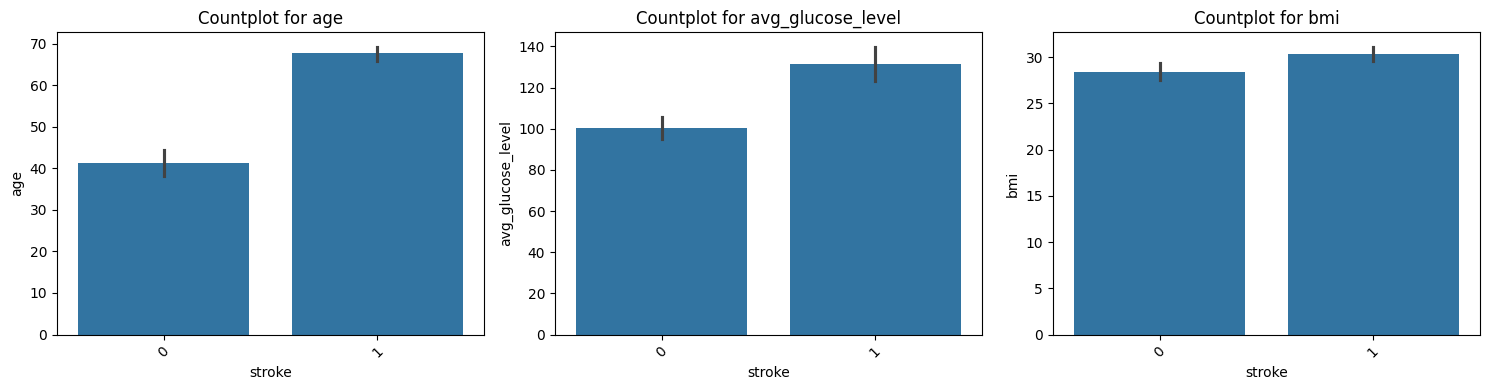

In [468]:
# Number of categorical columns
num_cols = len(num_col)

# Set up the subplot grid dimensions
rows = (num_cols + 2) // 3  # Adjust the number of rows based on the number of columns
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))  # Customize the size as needed
axes = axes.flatten()  # Flatten to iterate over axes easily

# Iterate through the categorical columns and plot countplots
for i, col in enumerate(num_col):
    sns.barplot(x = df_train['stroke'], y = df_train[col],ax=axes[i])

    axes[i].set_title(f'Countplot for {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels if needed

# Remove unused subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

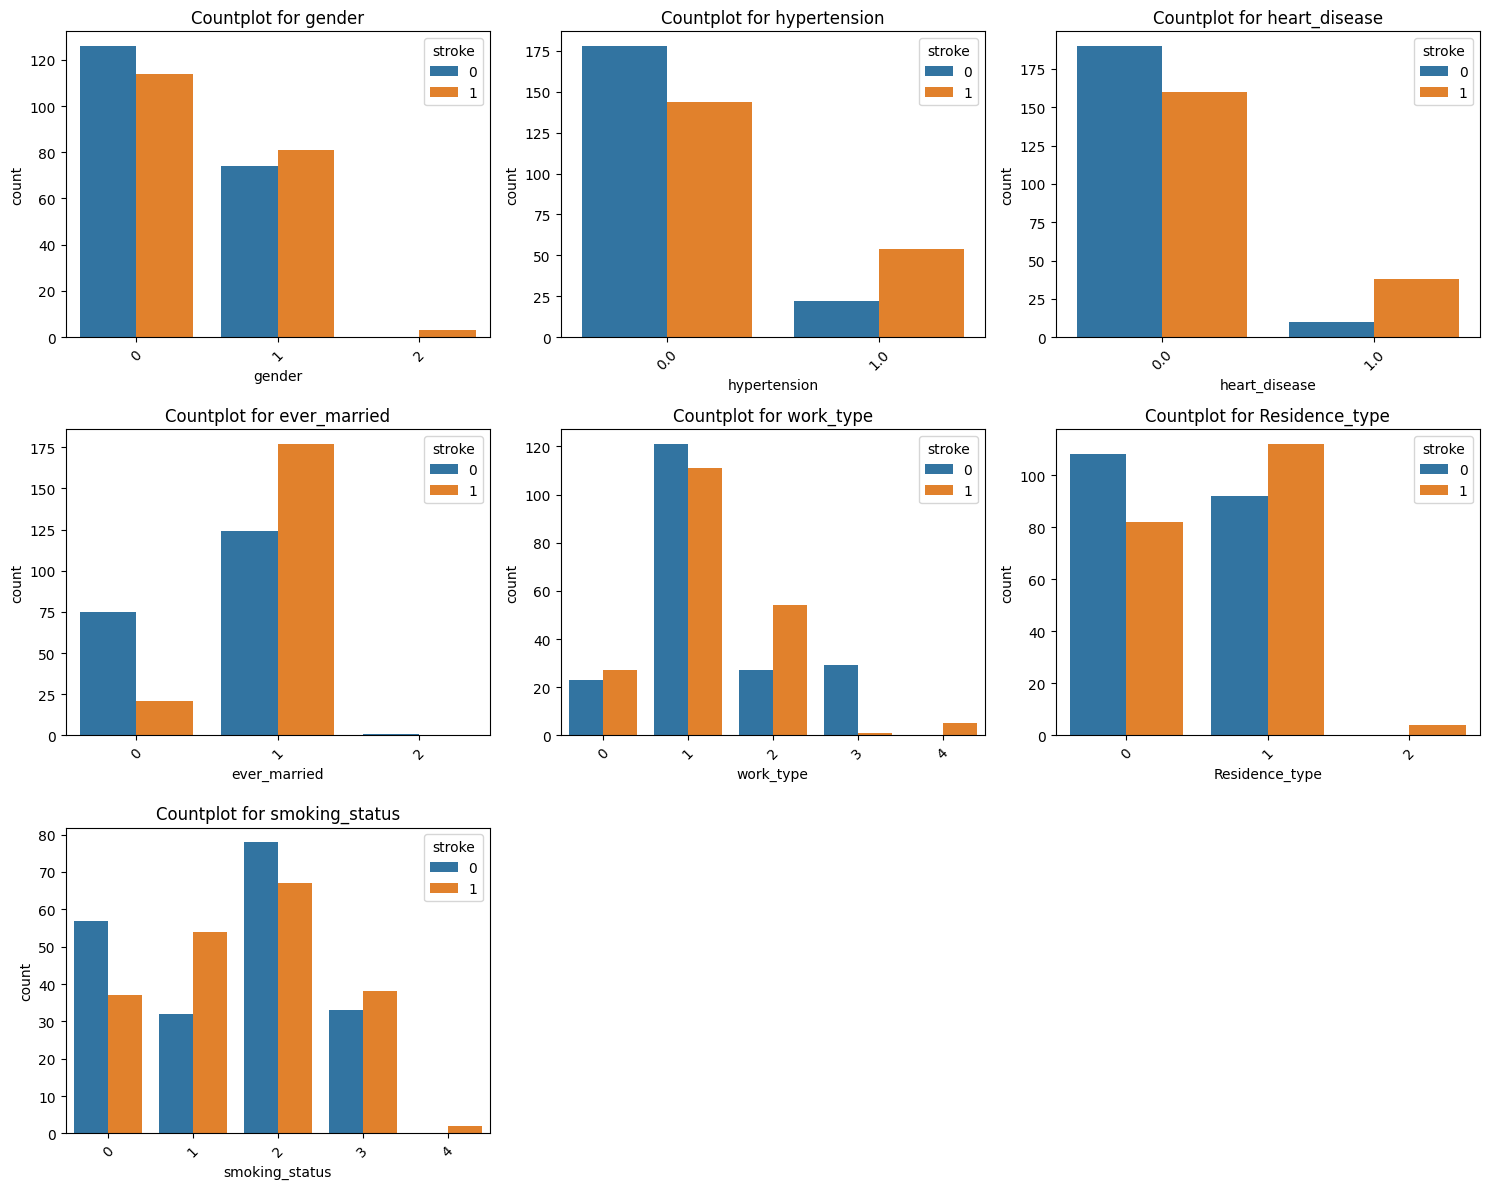

In [469]:
# Number of categorical columns
num_cols = len(cat_col)

# Set up the subplot grid dimensions
rows = (num_cols + 2) // 3  # Adjust the number of rows based on the number of columns
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))  # Customize the size as needed
axes = axes.flatten()  # Flatten to iterate over axes easily

# Iterate through the categorical columns and plot countplots
for i, col in enumerate(cat_col):
    sns.countplot(x=df_train[col], hue=df_train['stroke'], ax=axes[i])
    axes[i].set_title(f'Countplot for {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels if needed

# Remove unused subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

<Axes: >

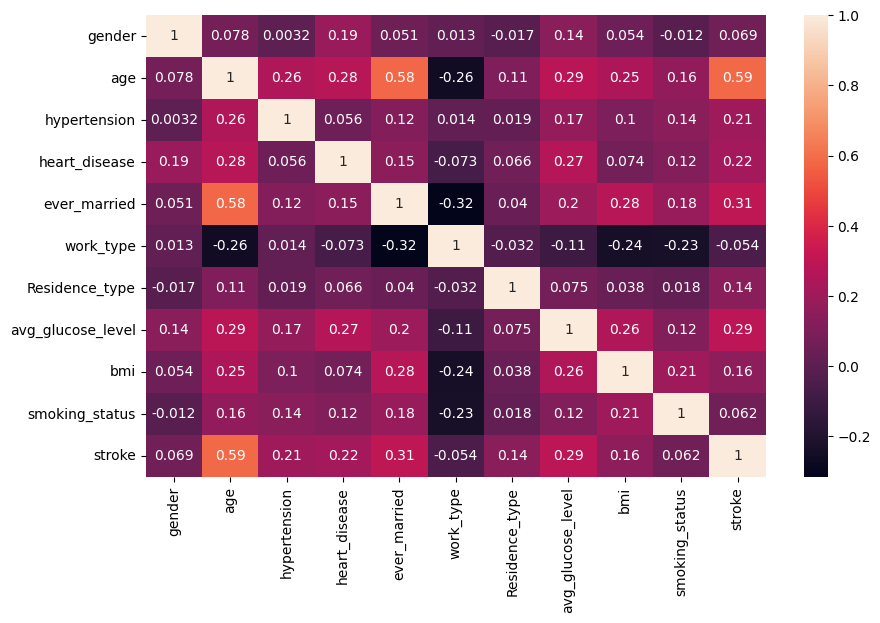

In [470]:
#change figure size
plt.figure(figsize=(10, 6))
sns.heatmap(df_train.corr(), annot=True)  #this is only for numeric values....

In [471]:
df_train.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [472]:
#1. set the X and y
X_train = df_train[ ['age', 'hypertension', 'avg_glucose_level', 'heart_disease'] ]
y_train = df_train['stroke']

X_test = df_test[ ['age', 'hypertension', 'avg_glucose_level', 'heart_disease'] ]
#no y_test, because this dataset does not have the answer....

#2. make sure the shape of X is (samples, features), and y is (samples, )
assert X_train.ndim == 2
assert X_test.ndim  == 2
assert y_train.ndim == 1

print("(samples, features): ", X_train.shape)
print("(samples,         ): ", y_train.shape)
print("(samples, features): ", X_test.shape)

(samples, features):  (398, 4)
(samples,         ):  (398,)
(samples, features):  (96, 4)


In [473]:
from sklearn.linear_model import LogisticRegression  #drawing a line based on linear regression but used for classification
from sklearn.naive_bayes import GaussianNB  #drawing a line based on probability

##Situational (but we don't use much)
from sklearn.neighbors import KNeighborsClassifier

##Complex
from sklearn.ensemble import RandomForestClassifier  #using trees to classify
from sklearn.svm import SVC  #drawing a line based on maximum distance
from sklearn.ensemble import GradientBoostingClassifier  #<<-------is the MOST complex
    #XGBoost but is not in sklearn, import XGBoost #<---most powerful algorithm for tabular data (not images, signal)

#any random_state you can use......up to you 
lr = LogisticRegression(random_state=999)
rf = RandomForestClassifier(random_state=999)
sv = SVC(random_state=999)

models = [lr, rf, sv]

#3.2 perform cross validation using KFold
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits = 5, shuffle = True, random_state=999)

for model in models:
    score = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')  #f1, recall, precision, accuracy
    print("Scores: ", score, "- Scores mean: ", score.mean(), "- Scores std (lower better): ", score.std())  #out of 1 ; 1 means perfect accuracy

Scores:  [0.725      0.775      0.8        0.73417722 0.7721519 ] - Scores mean:  0.7612658227848101 - Scores std (lower better):  0.027772192285028863
Scores:  [0.6875     0.675      0.7        0.70886076 0.75949367] - Scores mean:  0.7061708860759495 - Scores std (lower better):  0.029013309909397357
Scores:  [0.7375     0.8125     0.775      0.72151899 0.78481013] - Scores mean:  0.7662658227848101 - Scores std (lower better):  0.03282538054730865


In [474]:
from sklearn.model_selection import GridSearchCV

model = LogisticRegression(random_state=999)  #<----this is the model I choose, after cross validation

param_grid = dict()
param_grid['solver'] = ['newton-cg', 'lbfgs', 'liblinear']  #this is listed in the sklearn website

#add more parameters here
#param_grid[parameter] = list of parameters to search

#refit means it will pick the best model, and fit again, so it means grid is already the best model after this line
grid = GridSearchCV(model, param_grid, scoring="accuracy", cv=kfold, refit=True, return_train_score=True)
#scoring = f1, recall, precision, accuracy

#fit the grid, which will basically do cross validation across all combinatiosn, here we only have 3 comb
grid.fit(X_train, y_train)  #remember to use only training set here....

#print the best parameters and accuracy
# print(grid.best_params_)
# print(grid.best_score_)
print(grid.cv_results_)


{'mean_fit_time': array([0.03001976, 0.04947653, 0.00332251]), 'std_fit_time': array([0.00687838, 0.01069976, 0.00406977]), 'mean_score_time': array([0.00572424, 0.00492334, 0.004913  ]), 'std_score_time': array([0.00302633, 0.00402115, 0.00401459]), 'param_solver': masked_array(data=['newton-cg', 'lbfgs', 'liblinear'],
             mask=[False, False, False],
       fill_value=np.str_('?'),
            dtype=object), 'params': [{'solver': 'newton-cg'}, {'solver': 'lbfgs'}, {'solver': 'liblinear'}], 'split0_test_score': array([0.725 , 0.725 , 0.7375]), 'split1_test_score': array([0.775, 0.775, 0.8  ]), 'split2_test_score': array([0.8   , 0.8   , 0.8125]), 'split3_test_score': array([0.73417722, 0.73417722, 0.73417722]), 'split4_test_score': array([0.7721519 , 0.7721519 , 0.78481013]), 'mean_test_score': array([0.76126582, 0.76126582, 0.77379747]), 'std_test_score': array([0.02777219, 0.02777219, 0.03222734]), 'rank_test_score': array([2, 2, 1], dtype=int32), 'split0_train_score': array

0.8333333333333334
0.75
1.0
0.8571428571428571
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



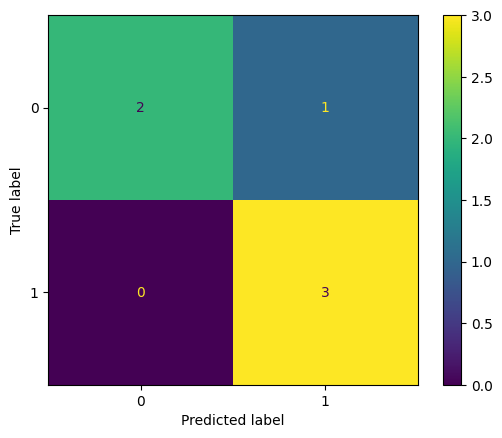

In [475]:
y     = [0, 0, 1, 1, 0, 1]
ypred = [1, 0, 1, 1, 0, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#if you want all in one table
from sklearn.metrics import classification_report

#if you want the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#format (ytrue, ypred)
print(accuracy_score(y, ypred))
print(precision_score(y, ypred))
print(recall_score(y, ypred))
print(f1_score(y, ypred))

print(classification_report(y, ypred))

cm = confusion_matrix(y, ypred)
cmp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])

cmp.plot()

#for regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [476]:
pred_y = grid.predict(X_test)

print(pred_y)

[0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1
 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 0 1
 0 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1]


In [477]:
fake_y_test = np.random.randint(0, 2, size = (pred_y.shape))

In [478]:
accuracy_score(fake_y_test, pred_y)

0.4791666666666667

In [479]:
grid.best_estimator_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,999
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [480]:
grid.best_estimator_.coef_

array([[0.06154871, 0.30845112, 0.00412708, 0.30538676]])

<Axes: ylabel='features'>

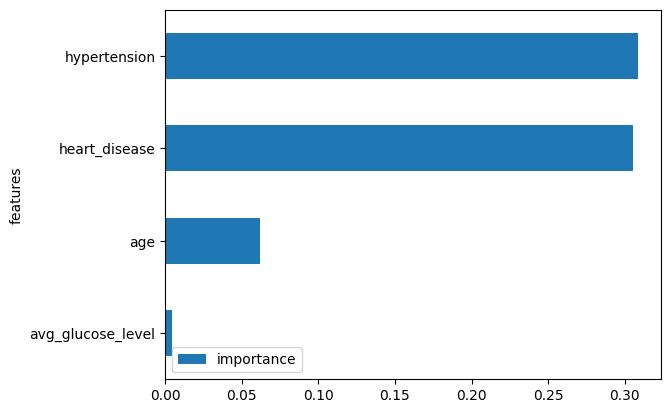

In [481]:
feature_importance = pd.DataFrame(['age', 'hypertension', 'avg_glucose_level', 'heart_disease'], 
                                  columns=['features'])
feature_importance["importance"] = grid.best_estimator_.coef_[0]

feature_importance = feature_importance.sort_values(by = ['importance'], ascending=True)

feature_importance.plot.barh(x='features', y='importance')

In [482]:
import pickle

# save the model
filename = 'model/Loan_Prediction.pkl' # pkl does not matter, you can do .everything
pickle.dump(grid, open(filename,'wb'))

# Load the model
loaded_grid=pickle.load(open(filename,'rb'))


In [483]:
# Select the first row by position
df_train[['age', 'hypertension', 'avg_glucose_level', 'heart_disease', 'stroke']].iloc[0]

age                   54.00
hypertension           0.00
avg_glucose_level    109.51
heart_disease          0.00
stroke                 0.00
Name: 1514, dtype: float64

In [484]:
sample = np.array([[54, 0, 109, 0]])

In [485]:
predicted_stroke= loaded_grid.predict(sample)
predicted_stroke

d:\Machine learning\ML Classwork 1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])